In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Task 3 environment ready!")

Task 3 environment ready!


In [2]:
df = pd.read_csv("cleaned_sales_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 21)


,Order_ID,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_Weekday,Customer_ID,Customer_Name,Age,Age_Group,...,City,Product,Category,Quantity,Unit_Price,Total_Sales,Is_Sales_Outlier,Age_Imputed,City_Imputed,Is_Duplicate_ID_Fixed
0,ORD100002,2025-02-25,2025,February,1,Tuesday,CUST5529,Customer_227,30,26-35,...,Bengaluru,Rice,Grocery,7,2829.77,19808.39,False,False,False,False
1,ORD100003,2025-10-14,2025,October,4,Tuesday,CUST3127,Customer_182,63,56-65,...,Bengaluru,Book,Education,5,27906.16,139530.80,False,False,False,False
2,ORD100004,2025-05-13,2025,May,2,Tuesday,CUST8887,Customer_487,62,56-65,...,Bengaluru,Book,Education,8,37491.06,299928.48,False,False,False,False
3,ORD100005,2025-12-02,2025,December,4,Tuesday,CUST2515,Customer_470,65,56-65,...,Kolkata,Mobile,Electronics,9,28541.36,256872.24,False,False,False,False
4,ORD100006,2025-11-20,2025,November,4,Thursday,CUST4796,Customer_380,44,36-45,...,Bengaluru,Rice,Grocery,10,14036.59,140365.90,False,False,False,False


In [3]:
print("Columns:")
for col in df.columns:
    print("-", col)

Columns:
- Order_ID
- Order_Date
- Order_Year
- Order_Month
- Order_Quarter
- Order_Weekday
- Customer_ID
- Customer_Name
- Age
- Age_Group
- Gender
- City
- Product
- Category
- Quantity
- Unit_Price
- Total_Sales
- Is_Sales_Outlier
- Age_Imputed
- City_Imputed
- Is_Duplicate_ID_Fixed


## Core Key Performance Indicators (KPIs)

### 1. Total Revenue
**Formula:** Sum of Total Sales  
**Purpose:** Measures the overall revenue generated by the business.

### 2. Total Orders
**Formula:** Count of Unique Order IDs  
**Purpose:** Measures the total number of customer orders.

### 3. Average Order Value (AOV)
**Formula:** Total Revenue / Total Orders  
**Purpose:** Measures the average revenue generated per order.

### 4. Total Customers
**Formula:** Count of Unique Customer IDs  
**Purpose:** Measures the size of the active customer base.

### 5. Revenue per Customer
**Formula:** Total Revenue / Total Customers  
**Purpose:** Measures the average revenue generated by each customer.

In [4]:
# Core KPI Calculations

total_revenue = df['Total_Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()

average_order_value = total_revenue / total_orders
revenue_per_customer = total_revenue / total_customers

print("----- CORE KPIs -----")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Revenue per Customer: ₹{revenue_per_customer:,.2f}")

----- CORE KPIs -----
Total Revenue: ₹139,399,439.65
Total Orders: 1,000
Average Order Value: ₹139,399.44
Total Customers: 947
Revenue per Customer: ₹147,201.10


In [5]:
# Customer-level revenue analysis

customer_analysis = (
    df.groupby('Customer_ID')
      .agg(
          Total_Revenue=('Total_Sales', 'sum'),
          Total_Orders=('Order_ID', 'nunique')
      )
      .reset_index()
)

customer_analysis['Average_Order_Value'] = (
    customer_analysis['Total_Revenue'] /
    customer_analysis['Total_Orders']
)

customer_analysis.head()

,Customer_ID,Total_Revenue,Total_Orders,Average_Order_Value
0,CUST1004,8321.54,1,8321.54
1,CUST1017,264230.68,1,264230.68
2,CUST1026,164965.29,1,164965.29
3,CUST1032,146990.90,1,146990.90
4,CUST1038,37068.40,1,37068.40


In [6]:
customer_analysis['Customer_Segment'] = pd.qcut(
    customer_analysis['Total_Revenue'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_analysis.head(10)

,Customer_ID,Total_Revenue,Total_Orders,Average_Order_Value,Customer_Segment
0,CUST1004,8321.54,1,8321.54,Low Value
1,CUST1017,264230.68,1,264230.68,High Value
2,CUST1026,164965.29,1,164965.29,Medium Value
3,CUST1032,146990.90,1,146990.90,Medium Value
4,CUST1038,37068.40,1,37068.40,Low Value
5,CUST1049,16714.64,1,16714.64,Low Value
6,CUST1088,203819.75,1,203819.75,High Value
7,CUST1090,5263.79,1,5263.79,Low Value
8,CUST1094,211945.90,1,211945.90,High Value
9,CUST1104,90746.36,1,90746.36,Medium Value


In [7]:
segment_summary = (
    customer_analysis
    .groupby('Customer_Segment', observed=True)
    .agg(
        Customers=('Customer_ID', 'count'),
        Total_Revenue=('Total_Revenue', 'sum'),
        Average_Revenue=('Total_Revenue', 'mean'),
        Average_Orders=('Total_Orders', 'mean')
    )
    .reset_index()
)

segment_summary

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Orders
0,Low Value,316,10371392.73,32820.863070,1.009494
1,Medium Value,315,36663823.45,116393.090317,1.038095
2,High Value,316,92364223.47,292291.846424,1.120253


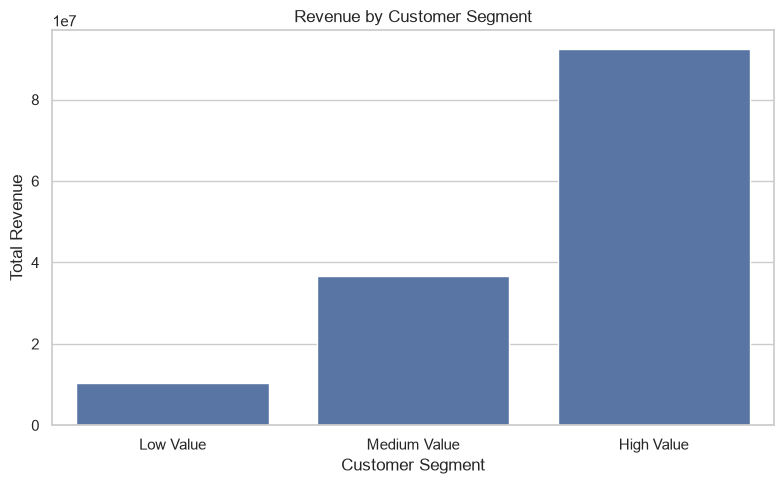

In [8]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x='Customer_Segment',
    y='Total_Revenue'
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

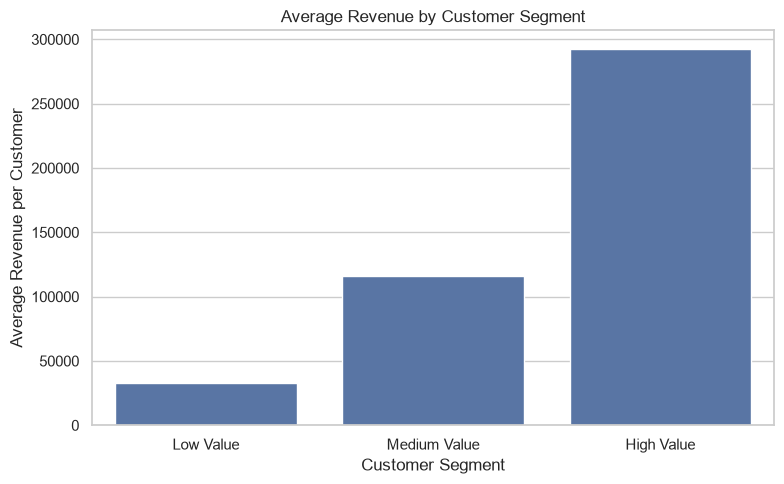

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x='Customer_Segment',
    y='Average_Revenue'
)

plt.title('Average Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Revenue per Customer')
plt.tight_layout()
plt.show()

In [10]:
segment_summary['Revenue_Share_%'] = (
    segment_summary['Total_Revenue']
    / segment_summary['Total_Revenue'].sum()
    * 100
)

segment_summary[
    ['Customer_Segment', 'Customers',
     'Total_Revenue', 'Revenue_Share_%']
]

,Customer_Segment,Customers,Total_Revenue,Revenue_Share_%
0,Low Value,316,10371392.73,7.440053
1,Medium Value,315,36663823.45,26.301270
2,High Value,316,92364223.47,66.258676


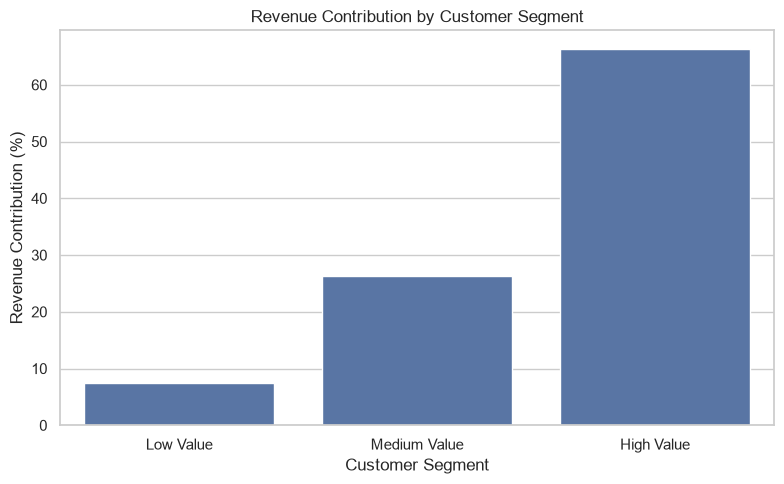

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x='Customer_Segment',
    y='Revenue_Share_%'
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue Contribution (%)')
plt.tight_layout()
plt.show()

In [12]:
top_customers = (
    customer_analysis
    .sort_values('Total_Revenue', ascending=False)
    .head(10)
)

top_customers[
    ['Customer_ID', 'Total_Revenue',
     'Total_Orders', 'Average_Order_Value',
     'Customer_Segment']
]

,Customer_ID,Total_Revenue,Total_Orders,Average_Order_Value,Customer_Segment
889,CUST9510,867333.24,2,433666.620,High Value
600,CUST6845,769479.75,2,384739.875,High Value
558,CUST6532,610981.74,2,305490.870,High Value
512,CUST6082,548416.39,2,274208.195,High Value
283,CUST3689,542484.08,2,271242.040,High Value
287,CUST3730,538633.97,2,269316.985,High Value
383,CUST4706,528036.44,2,264018.220,High Value
915,CUST9693,511421.86,2,255710.930,High Value
661,CUST7374,511309.40,2,255654.700,High Value
109,CUST2062,493677.50,1,493677.500,High Value


In [13]:
category_analysis = (
    df.groupby('Category')
      .agg(
          Total_Revenue=('Total_Sales', 'sum'),
          Total_Orders=('Order_ID', 'nunique'),
          Total_Quantity=('Quantity', 'sum')
      )
      .reset_index()
      .sort_values('Total_Revenue', ascending=False)
)

category_analysis

,Category,Total_Revenue,Total_Orders,Total_Quantity
1,Electronics,50778581.70,354,1978
0,Education,25031689.40,178,977
4,Grocery,22231711.28,153,826
3,Furniture,21521561.48,159,855
2,Fashion,19835895.79,156,799


In [14]:
category_analysis['Revenue_Share_%'] = (
    category_analysis['Total_Revenue']
    / category_analysis['Total_Revenue'].sum()
    * 100
)

category_analysis

,Category,Total_Revenue,Total_Orders,Total_Quantity,Revenue_Share_%
1,Electronics,50778581.70,354,1978,36.426676
0,Education,25031689.40,178,977,17.956808
4,Grocery,22231711.28,153,826,15.948207
3,Furniture,21521561.48,159,855,15.438772
2,Fashion,19835895.79,156,799,14.229538


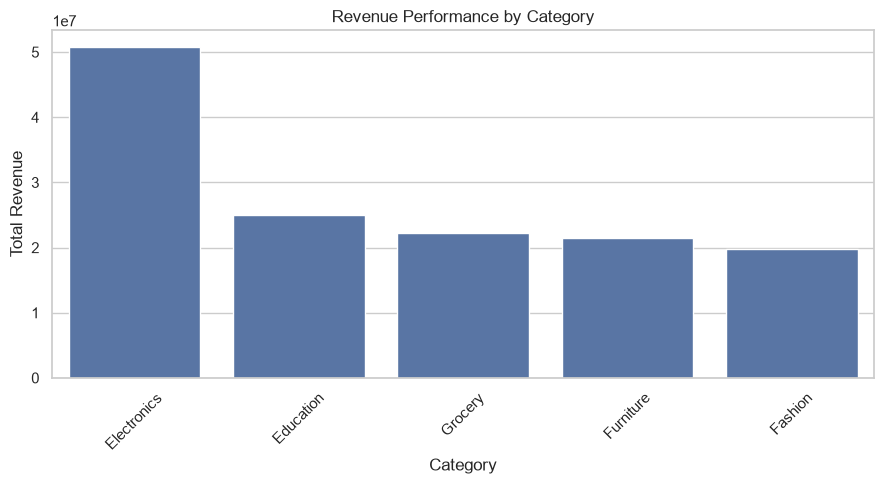

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_analysis,
    x='Category',
    y='Total_Revenue'
)

plt.title('Revenue Performance by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
product_analysis = (
    df.groupby('Product')
      .agg(
          Total_Revenue=('Total_Sales', 'sum'),
          Total_Orders=('Order_ID', 'nunique'),
          Total_Quantity=('Quantity', 'sum')
      )
      .reset_index()
      .sort_values('Total_Revenue', ascending=False)
)

top_10_products = product_analysis.head(10)

top_10_products

,Product,Total_Revenue,Total_Orders,Total_Quantity
2,Laptop,25443008.51,170,970
3,Mobile,25335573.19,184,1008
0,Book,25031689.40,178,977
4,Rice,22231711.28,153,826
1,Chair,21521561.48,159,855
5,Shoes,19835895.79,156,799


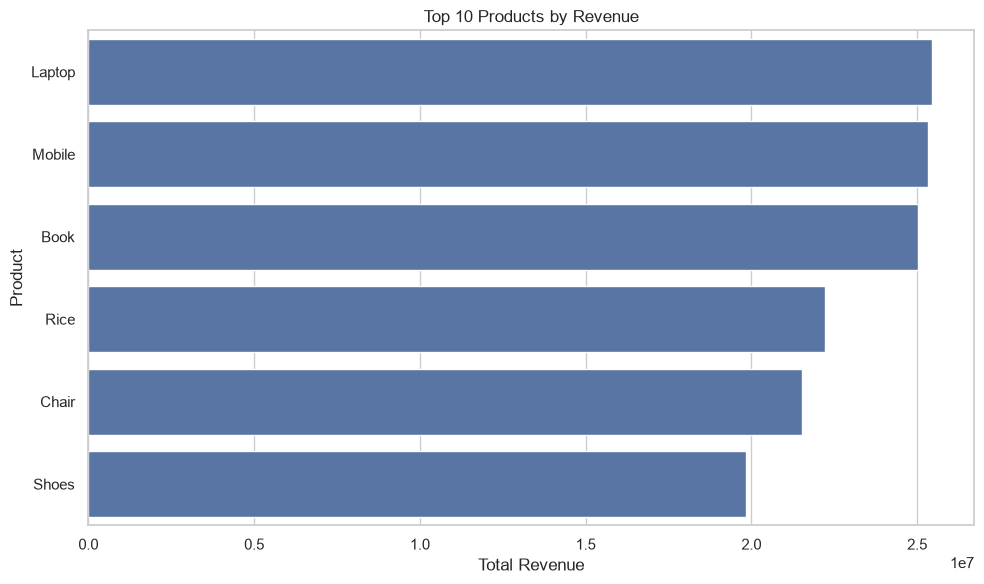

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_products,
    x='Total_Revenue',
    y='Product'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [18]:
best_product = product_analysis.iloc[0]

print("----- TOP PRODUCT -----")
print("Product:", best_product['Product'])
print(f"Revenue: ₹{best_product['Total_Revenue']:,.2f}")
print("Orders:", int(best_product['Total_Orders']))
print("Quantity Sold:", int(best_product['Total_Quantity']))

----- TOP PRODUCT -----
Product: Laptop
Revenue: ₹25,443,008.51
Orders: 170
Quantity Sold: 970


In [19]:
print("========== TASK 3 DEEP-DIVE SUMMARY ==========")

print(f"\nTotal Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Revenue per Customer: ₹{revenue_per_customer:,.2f}")

print("\nTop Category:")
print(category_analysis.iloc[0][['Category', 'Total_Revenue']])

print("\nTop Product:")
print(product_analysis.iloc[0][['Product', 'Total_Revenue']])

print("\nCustomer Segment Performance:")
print(
    segment_summary[
        ['Customer_Segment', 'Customers',
         'Total_Revenue', 'Revenue_Share_%']
    ]
)

========== TASK 3 DEEP-DIVE SUMMARY ==========

Total Revenue: ₹139,399,439.65
Total Orders: 1,000
Average Order Value: ₹139,399.44
Total Customers: 947
Revenue per Customer: ₹147,201.10

Top Category:
Category         Electronics
Total_Revenue     50778581.7
Name: 1, dtype: object

Top Product:
Product               Laptop
Total_Revenue    25443008.51
Name: 2, dtype: object

Customer Segment Performance:
  Customer_Segment  Customers  Total_Revenue  Revenue_Share_%
0        Low Value        316    10371392.73         7.440053
1     Medium Value        315    36663823.45        26.301270
2       High Value        316    92364223.47        66.258676


## Deep-Dive Business Insights

### Customer Segmentation
- Customers were segmented into Low Value, Medium Value, and High Value groups based on their total revenue contribution.
- High-value customers represent the most commercially important customer segment.
- Revenue contribution across segments helps identify where customer retention and engagement efforts should be prioritized.

### Product Performance
- Product-level analysis identified the strongest revenue-generating products.
- Top-performing products can be prioritized in promotions, inventory planning, and sales strategies.

### Category Performance
- Category-level revenue analysis highlights the business areas contributing most strongly to overall sales.
- Revenue share provides a clearer comparison of the relative importance of each category.

### Business Recommendation
- Prioritize retention strategies for high-value customers.
- Promote high-performing products while investigating opportunities to improve weaker products.
- Allocate marketing and inventory resources according to category and product revenue performance.
- Track these KPIs through an interactive dashboard for continuous business monitoring.

In [20]:
# Add customer segment back to transaction-level dataset

dashboard_data = df.merge(
    customer_analysis[
        ['Customer_ID', 'Customer_Segment']
    ],
    on='Customer_ID',
    how='left'
)

dashboard_data.head()

,Order_ID,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_Weekday,Customer_ID,Customer_Name,Age,Age_Group,...,Product,Category,Quantity,Unit_Price,Total_Sales,Is_Sales_Outlier,Age_Imputed,City_Imputed,Is_Duplicate_ID_Fixed,Customer_Segment
0,ORD100002,2025-02-25,2025,February,1,Tuesday,CUST5529,Customer_227,30,26-35,...,Rice,Grocery,7,2829.77,19808.39,False,False,False,False,Low Value
1,ORD100003,2025-10-14,2025,October,4,Tuesday,CUST3127,Customer_182,63,56-65,...,Book,Education,5,27906.16,139530.80,False,False,False,False,Medium Value
2,ORD100004,2025-05-13,2025,May,2,Tuesday,CUST8887,Customer_487,62,56-65,...,Book,Education,8,37491.06,299928.48,False,False,False,False,High Value
3,ORD100005,2025-12-02,2025,December,4,Tuesday,CUST2515,Customer_470,65,56-65,...,Mobile,Electronics,9,28541.36,256872.24,False,False,False,False,High Value
4,ORD100006,2025-11-20,2025,November,4,Thursday,CUST4796,Customer_380,44,36-45,...,Rice,Grocery,10,14036.59,140365.90,False,False,False,False,Medium Value


In [21]:
print(dashboard_data.columns)
print(dashboard_data['Customer_Segment'].value_counts())

Index(['Order_ID', 'Order_Date', 'Order_Year', 'Order_Month', 'Order_Quarter',
       'Order_Weekday', 'Customer_ID', 'Customer_Name', 'Age', 'Age_Group',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Is_Sales_Outlier', 'Age_Imputed', 'City_Imputed',
       'Is_Duplicate_ID_Fixed', 'Customer_Segment'],
      dtype='str')
Customer_Segment
High Value      354
Medium Value    327
Low Value       319
Name: count, dtype: int64


In [22]:
dashboard_data.to_csv(
    "task3_dashboard_data.csv",
    index=False
)

print("Power BI dashboard dataset created successfully!")

Power BI dashboard dataset created successfully!
